# Black-Gold 🛢️
### Does the price of oil predict the stock market?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates out of sample?: Busted](https://img.shields.io/badge/Replicates_out_of_sample%3F-Busted-8b949e?style=flat-square)

A famous, intriguing claim: when oil rises this month, stocks fall next month — a delayed reaction you could trade. We test it on every month of tradable oil-futures data since 2000. The relationship is gone: not just weak, but the *wrong sign* and not significant — and a rule built on it badly trails simply buying and holding.

> 📓 **Plain-language layer.** The regression and the sub-period slopes are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (black_gold/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from black_gold import data, strategy as st
d = data.fetch_pair()                          # cache-first; built by examples/verify.py --fetch
reg = st.predict_regression(d["oil"], d["eq"])
timing, bh = st.oil_timing(d["oil"], d["eq"]), st.buy_hold(d["eq"])


## The answer first 🎯

| The claim | The data (2000–2026) |
|---|---|
| "Oil up → stocks down next month" | Slope **+0.017** (wrong sign), **t = 0.6** (insignificant). |
| "Trade it with an oil timer" | Timing Sharpe **0.26** vs buy-and-hold **0.42**. |
| "A robust cross-asset signal" | Absent in 2000–2008 *and* 2009-on. |

## 1 · The claim

Driesprong, Jacobsen & Maat (2008): oil-price changes negatively forecast next month's equity returns — markets underreact to oil, so last month's oil move leaks into this month's stocks. Documented across many countries, 1973–2003.

## 2 · So what?

A single, public commodity price predicting the whole stock market would be a remarkable, tradable cross-asset edge. But a predictability documented on 1973–2003 is a *bet about the future* — and the only honest test is whether it still works on data you could trade.

## 3 · How would we even know?

Regress this month's S&P return on last month's oil return (is the slope negative and significant?), then build the timing rule — long equities after oil falls — and race it against buy-and-hold.

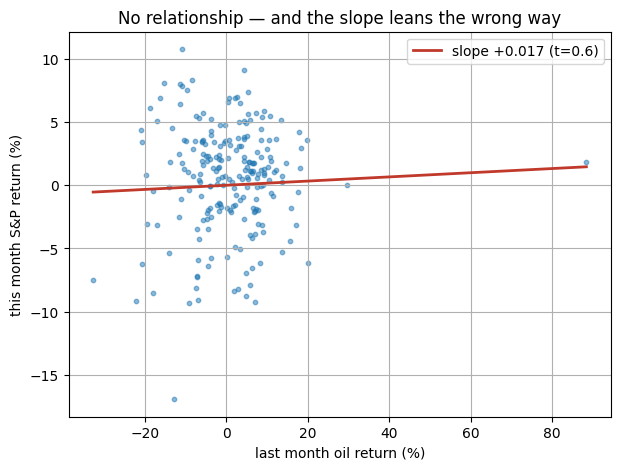

In [2]:
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(d['oil'].shift(1)*100, d['eq']*100, s=10, alpha=.5)
xs=np.linspace(d['oil'].min()*100, d['oil'].max()*100, 50)
ax.plot(xs, (reg['slope']*xs/100 + 0)*100, color='#c0392b', lw=2, label=f"slope {reg['slope']:+.3f} (t={reg['tstat']:.1f})")
ax.set_xlabel('last month oil return (%)'); ax.set_ylabel('this month S&P return (%)')
ax.set_title('No relationship — and the slope leans the wrong way'); ax.legend(); plt.show()

## 4 · The teardown

The scatter is a cloud. The timing rule, holding cash whenever oil rose, simply gives up half the market's return.

,cagr,sharpe,max_drawdown
oil timing,2.2%,0.26,-38%
buy & hold S&P,5.1%,0.42,-41%


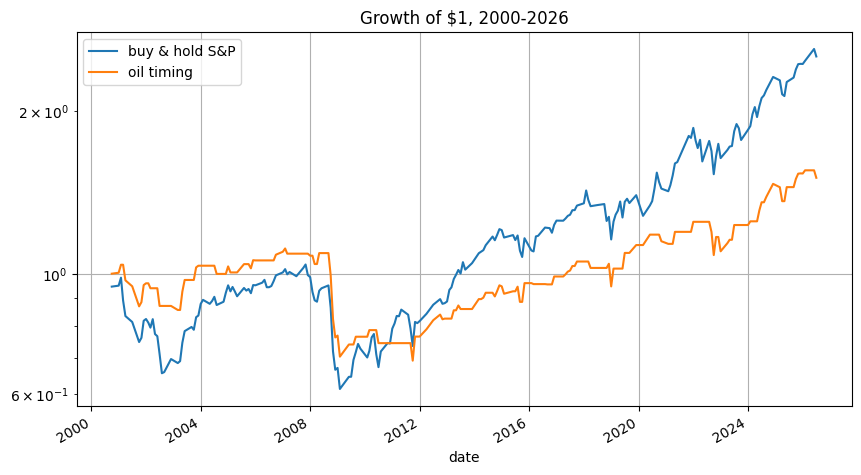

In [3]:
rows={'oil timing':st.summary(timing),'buy & hold S&P':st.summary(bh)}
t=pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']]
display(t.style.format({'cagr':'{:.1%}','sharpe':'{:.2f}','max_drawdown':'{:.0%}'}))
eqT=(1+timing).cumprod(); eqB=(1+bh).cumprod()
ax=eqB.plot(label='buy & hold S&P',lw=1.5); eqT.plot(ax=ax,label='oil timing',lw=1.5)
ax.set_yscale('log'); ax.set_title('Growth of $1, 2000-2026'); ax.legend(); plt.show()

**Read it plainly.** Conditioning on oil doesn't dodge anything — it just keeps you out of the market for no reason. The cross-asset crystal ball is cloudy.

## 5 · The verdict

**Signal: None** — insignificant, wrong sign. **Tradability: Mirage** — the timer trails buy-and-hold. **Replicates out of sample?: Busted.**

## 6 · Could you actually trade it?

You could code the oil timer in five lines — and you'd underperform a do-nothing index investor while taking on whipsaw risk. There's no edge to extract from last month's oil price.

## 7 · Going further 🚪

The quants notebook shows the slope is insignificant in every sub-period. This closes the second five-study bench. Next up (if you continue): the 52-week high effect — [Study 50 High-Water](../../50-high-water/).